# Credit Risk Exploratory Analysis
### Dataset: Home Credit Default Risk (Kaggle)

Mục tiêu: ôn lại SQL + pandas nền tảng, đồng thời luyện áp dụng **Khung đặt câu hỏi domain** (So sánh → Độ lớn → Nguyên nhân → Hệ quả) vào dữ liệu tín dụng thật.

Mỗi câu hỏi bên dưới có 2 phần:
- Ô code để bạn tự viết SQL (dùng `duckdb` hoặc `sqlite3` để chạy SQL trực tiếp trên DataFrame) và/hoặc pandas
- Ô "Insight" để bạn tự trả lời bằng lời — đây là phần quan trọng nhất, không phải code

> Gợi ý: cài `duckdb` (`pip install duckdb --break-system-packages`) để chạy SQL trực tiếp trên pandas DataFrame mà không cần dựng database riêng: `duckdb.sql("SELECT ... FROM df")`.


In [2]:
import pandas as pd
import duckdb  # bỏ comment nếu dùng SQL qua duckdb
import matplotlib.pyplot as plt

df = pd.read_csv("application_train.csv/application_train.csv")
df.shape



(307511, 122)

---
## Phần 1 — Nền tảng: GROUP BY, tỷ lệ, so sánh nhóm


### Câu 1 — Tỷ lệ vỡ nợ theo trình độ học vấn
Tính tỷ lệ vỡ nợ (default rate = trung bình của `TARGET`) theo từng nhóm `NAME_EDUCATION_TYPE`, sắp xếp giảm dần.

*Đây là câu bạn từng làm dở — sửa lại lỗi JOIN/CTE lần này.*


In [3]:
# SQL (qua duckdb) hoặc pandas groupby
df1 = df[["SK_ID_CURR", "TARGET", "CODE_GENDER", "NAME_CONTRACT_TYPE", "AMT_INCOME_TOTAL", "AMT_CREDIT","NAME_EDUCATION_TYPE" ]]
duckdb.sql("""
    with cte1 (total, "NAME_EDUCATION_TYPE") as 
    (
        select count(*), NAME_EDUCATION_TYPE as total
        from df1
        where TARGET = 1
        group by NAME_EDUCATION_TYPE
    )
    SELECT df1.NAME_EDUCATION_TYPE, (cte1.total/count(TARGET)) *1.0 as default_rate,    
    from df1 
    JOIN cte1 ON cte1."NAME_EDUCATION_TYPE" = df1."NAME_EDUCATION_TYPE" 
    group by df1."NAME_EDUCATION_TYPE", cte1.total 
    ORDER BY default_rate DESC 

    """)



┌───────────────────────────────┬──────────────────────┐
│      NAME_EDUCATION_TYPE      │     default_rate     │
│            varchar            │        double        │
├───────────────────────────────┼──────────────────────┤
│ Lower secondary               │  0.10927672955974843 │
│ Secondary / secondary special │  0.08939928843221562 │
│ Incomplete higher             │  0.08484966429891992 │
│ Higher education              │  0.05355115344028425 │
│ Academic degree               │ 0.018292682926829267 │
└───────────────────────────────┴──────────────────────┘

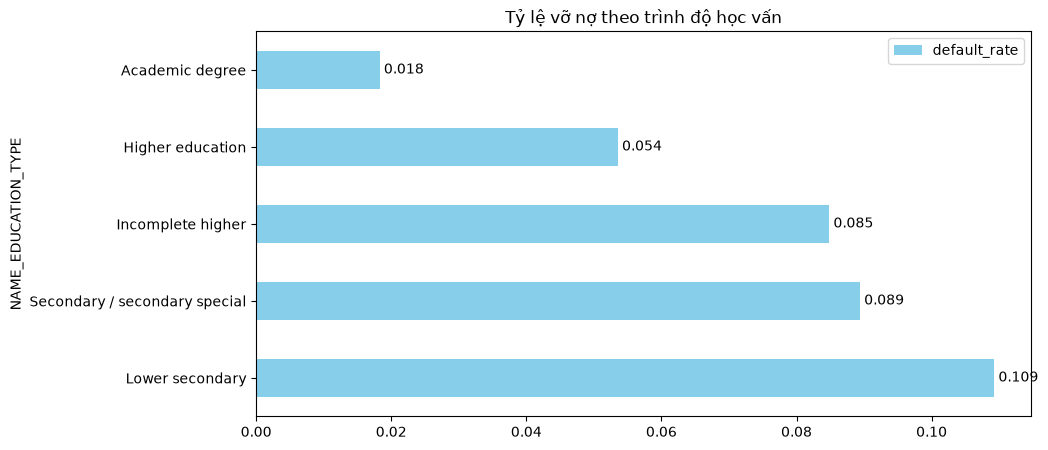

In [4]:
#CHUYỂN SANG PANDAS

df1 = df[["SK_ID_CURR", "TARGET", "CODE_GENDER", "NAME_CONTRACT_TYPE", "AMT_INCOME_TOTAL", "AMT_CREDIT","NAME_EDUCATION_TYPE" ]]
df2 = df1.groupby("NAME_EDUCATION_TYPE")["TARGET"].mean().reset_index(name ="default_rate").sort_values(by="default_rate", ascending = False)
ax = df2.set_index("NAME_EDUCATION_TYPE").plot(
    kind="barh",  
    title="Tỷ lệ vỡ nợ theo trình độ học vấn",
    figsize=(10, 5), # (Chiều rộng, Chiều cao) của khung hình
    color="skyblue"
)

# Dùng ax.containers[0] để lấy ra tập hợp các thanh cột vừa vẽ
ax.bar_label(
    ax.containers[0],          
    fmt='%.3f',                # Làm tròn 3 chữ số thập phân (VD: 0.109)
    padding=3                  # Khoảng cách từ số đến cái cột (cho đỡ dính vào nhau)
)
plt.show()




**Insight:**

**1. So sánh & Độ lớn:**
Nhìn vào dữ liệu, có một xu hướng tỷ lệ nghịch rất rõ ràng: **Trình độ học vấn càng cao thì tỷ lệ rủi ro vỡ nợ càng thấp.** Cụ thể, nhóm Lower secondary (Cấp 2) có tỷ lệ vỡ nợ cao nhất lên tới gần 11%. Tỷ lệ này giảm dần qua các cấp bậc và đạt mức thấp nhất ở nhóm Academic degree (Thạc sĩ/Tiến sĩ) với chỉ vỏn vẹn 1.83%.

**2. Vì sao lại như vậy?**
*   **Với nhóm học vấn thấp (Lower Secondary / Secondary):** Họ thường làm các công việc phổ thông, thu nhập thấp và thiếu tính ổn định. Ngoài ra, việc phải lăn lộn mưu sinh sớm có thể dẫn đến nhu cầu vay mượn cao nhưng lại thiếu đi kỹ năng quản lý tài chính cá nhân, dẫn đến mất khả năng trả nợ.
*   **Với nhóm học vấn cao (Higher Education / Academic degree):** Ngược lại, nhóm này có ưu thế cạnh tranh trên thị trường lao động, sở hữu công việc chuyên môn với thu nhập cao và dòng tiền ổn định. Họ cũng có nhận thức và kỹ năng quy hoạch tài chính cá nhân tốt hơn, giúp duy trì lịch sử tín dụng sạch.

**3. Ảnh hưởng và Hành động (Business Action):**
Biến "Học vấn" là một tín hiệu (feature) cực kỳ quan trọng trong mô hình chấm điểm tín dụng (Credit Scoring). Tổ chức tài chính có thể áp dụng các chính sách sau:
*   **Phân luồng rủi ro:** Phân loại nhóm Lower Secondary/Secondary vào tệp rủi ro cao (High-risk). 
*   **Thiết kế sản phẩm:** Khi cấp tín dụng cho nhóm này, hệ thống cần yêu cầu thêm giấy tờ chứng minh thu nhập, áp dụng hạn mức tín dụng (Credit Limit) thấp hơn, hoặc thu mức lãi suất cao hơn (Risk-based pricing) để bù đắp rủi ro tiềm ẩn. Ngược lại, có thể tung các gói vay ưu đãi để thu hút nhóm tệp khách hàng "ngon" như Higher Education/Academic.

### Câu 2 — Top 10% thu nhập cao nhất nhưng vẫn vỡ nợ
Tìm nhóm khách hàng thuộc top 10% thu nhập (`AMT_INCOME_TOTAL`) cao nhất, trong đó bao nhiêu % vẫn vỡ nợ (`TARGET = 1`)?

*Dùng `NTILE(10)` (SQL) hoặc `pd.qcut`/`quantile` (pandas) — đây là chỗ bạn từng vướng.*


In [5]:
duckdb.sql("""
WITH incomer AS(
SELECT SK_ID_CURR, TARGET, AMT_INCOME_TOTAL, NTILE(10) OVER (ORDER BY AMT_INCOME_TOTAL DESC) as income_rank
FROM df1)
SELECT AVG(TARGET) as default_rate_high_incomer
FROM incomer 
WHERE income_rank = 1
""")


┌───────────────────────────┐
│ default_rate_high_incomer │
│          double           │
├───────────────────────────┤
│       0.06256503642039542 │
└───────────────────────────┘

In [6]:
#CÁCH NTILE k hợp lý. 
#Cách 2

# Sử dụng thử cách Percent_rank()

duckdb.sql("""
WITH income_ranked AS (
    SELECT TARGET, PERCENT_RANK() OVER (ORDER BY AMT_INCOME_TOTAL ASC) AS pct_rank
    FROM df1
)
SELECT AVG(TARGET) AS DEFAULT_RATE
FROM income_ranked

WHERE pct_rank >= 0.9
""")

┌──────────────────────┐
│     DEFAULT_RATE     │
│        double        │
├──────────────────────┤
│ 0.061374765288465076 │
└──────────────────────┘

In [7]:
#Cách 3: 
duckdb.sql("""WITH muc_chuan AS (
    -- Tìm ra mức thu nhập chuẩn của mốc 90% (Top 10%)
    SELECT 
        PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY AMT_INCOME_TOTAL) AS top_10_threshold
    FROM df1
)
SELECT 
    AVG(df1.TARGET) AS default_rate
FROM df1, muc_chuan
-- Lấy tất cả những ai có thu nhập >= mức chuẩn (Sẽ lấy trọn gói những người bằng nhau)
WHERE df1.AMT_INCOME_TOTAL >= muc_chuan.top_10_threshold;
""")

┌────────────────────┐
│    default_rate    │
│       double       │
├────────────────────┤
│ 0.0636516794777298 │
└────────────────────┘

In [8]:
df1.describe() #mean target = 0.08 => tỷ lệ vỡ nợ trung bình 8%.
df1

,SK_ID_CURR,TARGET,CODE_GENDER,NAME_CONTRACT_TYPE,AMT_INCOME_TOTAL,AMT_CREDIT,NAME_EDUCATION_TYPE
0,100002,1,M,Cash loans,202500.0,406597.5,Secondary / secondary special
1,100003,0,F,Cash loans,270000.0,1293502.5,Higher education
2,100004,0,M,Revolving loans,67500.0,135000.0,Secondary / secondary special
3,100006,0,F,Cash loans,135000.0,312682.5,Secondary / secondary special
4,100007,0,M,Cash loans,121500.0,513000.0,Secondary / secondary special
...,...,...,...,...,...,...,...
307506,456251,0,M,Cash loans,157500.0,254700.0,Secondary / secondary special
307507,456252,0,F,Cash loans,72000.0,269550.0,Secondary / secondary special
307508,456253,0,F,Cash loans,153000.0,677664.0,Higher education
307509,456254,1,F,Cash loans,171000.0,370107.0,Secondary / secondary special


In [9]:
#CHUYỂN SANG PANDAS SẼ NHƯ THẾ NÀO? Hàm quantile đếm từ dưới lên. Giống hàm percentile_cont. 
muc_thu_nhap_top_10 = df1["AMT_INCOME_TOTAL"].quantile(0.9) #NUMBER
df_sieu_giau = df1[df1["AMT_INCOME_TOTAL"] >=muc_thu_nhap_top_10]
print(df_sieu_giau["TARGET"].mean())


0.0636516794777298



**1. So với gì? Độ lớn thế nào?**
Tại nhóm 10% khách hàng có thu nhập cao nhất, tỷ lệ vỡ nợ ghi nhận ở mức 6,2% (thấp hơn so với mức trung bình của toàn hệ thống là khoảng 8%). Mặc dù không quá lớn, nhưng con số này thể hiện rằng: Cứ 1.000 người siêu giàu thì vẫn có tới 62 người mất khả năng trả nợ.

**2. Vì sao lại như vậy?**
Thu nhập cao giúp giảm tỷ lệ vỡ nợ chung, nhưng không bảo vệ khách hàng khỏi rủi ro tuyệt đối. Nhóm vỡ nợ trong tệp thu nhập cao này có thể đến từ các nguyên nhân phi thu nhập như: Kinh doanh phá sản, rủi ro pháp lý (đi tù, lừa đảo), hoặc do họ lạm dụng các đòn bẩy tài chính (vay đầu tư chứng khoán, bất động sản quá tay) dẫn đến đứt gãy dòng tiền thanh khoản.

**3. Ảnh hưởng và Hành động đề xuất (Business Impact/Action)?**
Insight này mang lại giá trị cảnh báo lớn cho hệ thống tín dụng: Ngân hàng **không được phép nới lỏng hoặc bỏ qua các quy trình thẩm định** chỉ vì khách hàng khai báo thu nhập khủng. 
Thay vì chỉ dựa vào `AMT_INCOME_TOTAL`, ngân hàng cần đánh giá chéo thêm các chỉ số khác như: Lịch sử tín dụng (CIC), Tỷ lệ nợ trên thu nhập (DTI - Debt to Income), và tính ổn định của nguồn thu (làm thuê hay làm chủ) trước khi phê duyệt các khoản vay hạn mức lớn cho nhóm này.

### Câu 3 — Tỷ lệ Credit/Income và khả năng vỡ nợ
Tạo cột `CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL`. So sánh tỷ lệ vỡ nợ giữa nhóm có tỷ lệ này cao (trên median) và nhóm thấp (dưới median).


In [10]:
df1["CREDIT_INCOME_RATIO"] = df1["AMT_CREDIT"] / df1["AMT_INCOME_TOTAL"]
med = df1["CREDIT_INCOME_RATIO"].median()

dfq31 = df1[df1["CREDIT_INCOME_RATIO"] >= med]
dfq32 = df1[df1["CREDIT_INCOME_RATIO"] <= med]

print(df1["TARGET"].mean())
print(dfq31["TARGET"].mean())
print(dfq32["TARGET"].mean())

0.08072881945686496
0.08055096705383505
0.08091515679669108


In [11]:
#Cách 2
import numpy as np

# Bước 1: Tính cột tỷ lệ và tìm Median
df1["CREDIT_INCOME_RATIO"] = df1["AMT_CREDIT"] / df1["AMT_INCOME_TOTAL"]
med = df1["CREDIT_INCOME_RATIO"].median()

# Bước 2: Dùng np.where (giống hệt CASE WHEN) để dán nhãn trực tiếp vào cột mới
df1["Nhom_Ty_Le"] = np.where(df1["CREDIT_INCOME_RATIO"] >= med, "1. Cao hơn Median", "2. Thấp hơn Median")

# Bước 3: Gom nhóm bằng cái nhãn vừa tạo và tính trung bình (cực kỳ lười và gọn)
ket_qua = df1.groupby("Nhom_Ty_Le")["TARGET"].agg(["mean", "count"])

print(ket_qua)


                        mean   count
Nhom_Ty_Le                          
1. Cao hơn Median   0.080551  153766
2. Thấp hơn Median  0.080907  153745


# CHỮA BÀI 
1. So với gì? Độ lớn thế nào? (Observation) Khi chia khách hàng làm 2 nửa (dựa trên mức trung vị là 3.26), tỷ lệ vỡ nợ của nhóm tỷ lệ vay/thu nhập cao và nhóm tỷ lệ vay/thu nhập thấp gần như không có sự khác biệt (cùng xoay quanh mức trung bình 8%).

2. Vì sao lại như vậy? (Root cause & Nuance) Nhìn lướt qua, ta dễ lầm tưởng tỷ lệ CREDIT_INCOME_RATIO không có tác động đến rủi ro tín dụng. Tuy nhiên, nguyên nhân là do việc chia đôi dữ liệu ở mức 3.26 là một mốc khá an toàn (vay gấp 3 lần thu nhập năm). Sự thật là rủi ro vỡ nợ không tăng theo đường thẳng, mà nó tập trung mạnh ở các điểm Outliers (Dị biệt). Khi tỷ lệ này bị đẩy lên quá cao (vay gấp 10 lần, 20 lần... thậm chí 84 lần thu nhập), tỷ lệ vỡ nợ của những người này sẽ tăng vọt do gánh nặng trả nợ vượt quá khả năng tài chính của họ.

3. Ảnh hưởng và Hành động (Business Impact/Action)? Do rủi ro không nằm ở đại đa số khách hàng mà nằm ở phần "đuôi" cực đoan, tổ chức tín dụng cần đưa ra các mốc chặn (Threshold):

Chấp nhận phê duyệt bình thường cho các mức vay gấp 3 - 5 lần thu nhập (nhóm xoay quanh median).
Đưa ra cảnh báo đỏ (Red flag) và siết chặt hạn mức tín dụng với những hồ sơ xin vay có tỷ lệ Credit/Income cao bất thường (ví dụ > 10), đặc biệt là trên nhóm khách hàng có thu nhập cơ bản thấp, nhằm tránh hiện tượng "bóng bóng nợ".

In [12]:
#WRITE BY SQL

duckdb.sql("""
WITH 
--- B1: Tính cột mới 
bang_ty_le AS (
    SELECT TARGET, (AMT_CREDIT/ AMT_INCOME_TOTAL) AS credit_income_ratio
    FROM df1
    ),
moc_median AS(
    SELECT MEDIAN(credit_income_ratio) as med_val
    FROM bang_ty_le
    )

--- b2: Tim phan loai nhom

SELECT CASE 
    WHEN credit_income_ratio >= (SELECT med_val FROM moc_median ) Then '1.Nửa cao'
    ELSE '2.Nửa thấp'
    END AS phan_nhom,
    AVG(TARGET) as default_rate,
    count(*) as so_luong

FROM bang_ty_le
GROUP BY phan_nhom
ORDER BY phan_nhom
""")


┌────────────┬─────────────────────┬──────────┐
│ phan_nhom  │    default_rate     │ so_luong │
│  varchar   │       double        │  int64   │
├────────────┼─────────────────────┼──────────┤
│ 1.Nửa cao  │ 0.08055096705383505 │   153766 │
│ 2.Nửa thấp │ 0.08090669615272042 │   153745 │
└────────────┴─────────────────────┴──────────┘

---
## Phần 2 — Đào sâu hơn: nhiều chiều, window functions, tương quan


### Câu 4 — Xếp hạng độ tuổi rủi ro nhất
Tạo nhóm tuổi (chuyển `DAYS_BIRTH` thành tuổi), dùng `RANK()`/`ROW_NUMBER()` (SQL) hoặc `rank()` (pandas) để xếp hạng các nhóm tuổi theo tỷ lệ vỡ nợ, từ cao xuống thấp.


In [13]:
#update lại df 1 cho p2

df1 = df[["SK_ID_CURR", "TARGET", "CODE_GENDER", "NAME_CONTRACT_TYPE", "AMT_INCOME_TOTAL", "AMT_CREDIT","NAME_EDUCATION_TYPE" ]]

df1["AGE"] =((df["DAYS_BIRTH"] * -1) / 365).astype(int)

df_age = df1.groupby("AGE")["TARGET"].agg(["mean", "count"]).reset_index()

df_age["rank"] = df_age["mean"].rank(method = 'dense', ascending = False).astype(int)

df_age = df_age.sort_values(by="rank")

df_age

,AGE,mean,count,rank
2,22,0.136720,2933,1
3,23,0.128667,4057,2
7,27,0.118924,8476,3
1,21,0.113238,1254,4
8,28,0.112226,7975,5
9,29,0.112125,7670,6
10,30,0.110684,7806,7
4,24,0.110371,3905,8
11,31,0.106721,8377,9
6,26,0.104363,4561,10


In [14]:
duckdb.sql(""" WITH AGE AS(
    SELECT CAST (FLOOR(ABS(DAYS_BIRTH)/365) AS INT) AS AGE, COUNT(TARGET) AS TOTAL, MEAN(TARGET) AS DEFAULT_RATE 
    FROM df
    GROUP BY  CAST(FLOOR(ABS(DAYS_BIRTH)/365) AS INT))
    SELECT AGE, TOTAL, DEFAULT_RATE, DENSE_RANK() OVER ( ORDER BY DEFAULT_RATE desc) as rank FROM AGE """)

┌───────┬───────┬──────────────────────┬───────┐
│  AGE  │ TOTAL │     DEFAULT_RATE     │ rank  │
│ int32 │ int64 │        double        │ int64 │
├───────┼───────┼──────────────────────┼───────┤
│    22 │  2933 │  0.13672008182748038 │     1 │
│    23 │  4057 │  0.12866650234163174 │     2 │
│    27 │  8476 │  0.11892402076451156 │     3 │
│    21 │  1254 │  0.11323763955342903 │     4 │
│    28 │  7975 │   0.1122257053291536 │     5 │
│    29 │  7670 │   0.1121251629726206 │     6 │
│    30 │  7806 │  0.11068408916218293 │     7 │
│    24 │  3905 │  0.11037131882202304 │     8 │
│    31 │  8377 │  0.10672078309657396 │     9 │
│    26 │  4561 │   0.1043630782723087 │    10 │
│     · │    ·  │            ·         │     · │
│     · │    ·  │            ·         │     · │
│     · │    ·  │            ·         │     · │
│    63 │  5197 │  0.05349239946122763 │    41 │
│    58 │  6268 │ 0.052169751116783666 │    42 │
│    64 │  5117 │  0.05120187609927692 │    43 │
│    60 │  6227 │  0



So với gì? Độ lớn: Nhóm 21-40 tuổi có tỷ lệ vỡ nợ cao vượt mức trung bình, đỉnh điểm nằm ở tuổi 21-25. Từ sau 40 tuổi, rủi ro vỡ nợ giảm mạnh. (Bỏ qua số liệu nhiễu ở tuổi 20 và 69 do tập mẫu quá bé).
Vì sao? Tuổi trẻ (21-40) thường là độ tuổi mới ra trường, kinh tế chưa ổn định, hay có nhu cầu mua sắm tiêu dùng cao (điện thoại, xe máy) nhưng dòng tiền trả nợ lại dễ đứt gãy. Nhóm >40 tuổi đã có tích lũy tài sản và công việc vững vàng hơn.
Ảnh hưởng / Giải pháp: Vì khách hàng trẻ là tập khách hàng mục tiêu lớn nhất của công ty tài chính, ta không thể cấm họ vay. Thay vào đó, áp dụng chiến lược "Thử lửa": Chỉ cấp các khoản vay nhỏ (vay mua trả góp POS) cho nhóm dưới 30 tuổi. Nếu có lịch sử trả nợ tốt, mới tiếp tục mở khóa các khoản vay tiền mặt (Cash Loan) giá trị lớn.

### Câu 5 — Tình trạng việc làm (DAYS_EMPLOYED) và rủi ro
So sánh tỷ lệ vỡ nợ giữa nhóm có thời gian làm việc (`DAYS_EMPLOYED`) lâu năm và nhóm mới đi làm. Lưu ý: dataset này có giá trị bất thường (outlier) ở cột này — kiểm tra trước khi phân tích.


In [15]:
duckdb.sql("""
WITH YEAR_WORK AS (
        SELECT ROUND(ABS(DAYS_EMPLOYED)/365, 1) AS YEAR_EMPLOYED
        FROM df
        )
        select * from YEAR_WORK
""")

┌────────────────────────┐
│     YEAR_EMPLOYED      │
│         double         │
├────────────────────────┤
│                    1.7 │
│                    3.3 │
│                    0.6 │
│                    8.3 │
│                    8.3 │
│                    4.4 │
│                    8.6 │
│                    1.2 │
│                 1000.7 │
│                    5.5 │
│                     ·  │
│                     ·  │
│                     ·  │
│                 1000.7 │
│                    6.4 │
│                   22.7 │
│                    8.7 │
│                    1.2 │
│                    7.4 │
│                   10.8 │
│                    3.8 │
│                    4.5 │
│                    0.9 │
└────────────────────────┘
          ? rows        
  (>9999 rows, 20 shown) 

In [16]:
duckdb.sql("""
--- Xu ly outlier truoc
WITH YEAR_WORK AS (
        SELECT CASE 
            WHEN ROUND((DAYS_EMPLOYED) *(-1) /365, 1) < 0 THEN NULL
            ELSE ROUND((DAYS_EMPLOYED) *(-1) /365, 1)
            END AS year_employed, SK_ID_CURR
        FROM df
)
SELECT 
CASE 
    WHEN yw.year_employed BETWEEN 0 AND 5 THEN 'Moi di lam'
    WHEN yw.year_employed IS NULL THEN 'That nghiep/Nghi huu'
    ELSE 'Lau nam' 
    END as phan_loai , COUNT(df.TARGET) as so_nguoi, ROUND(AVG(df.TARGET),4) as default_rate
FROM df
JOIN YEAR_WORK yw ON df.SK_ID_CURR = yw.SK_ID_CURR
GROUP BY CASE 
    WHEN yw.year_employed BETWEEN 0 AND 5 THEN 'Moi di lam'
    WHEN yw.year_employed IS NULL THEN 'That nghiep/Nghi huu'
    ELSE 'Lau nam' 
    END

   """)

┌──────────────────────┬──────────┬──────────────┐
│      phan_loai       │ so_nguoi │ default_rate │
│       varchar        │  int64   │    double    │
├──────────────────────┼──────────┼──────────────┤
│ That nghiep/Nghi huu │    55374 │        0.054 │
│ Moi di lam           │   137261 │       0.1055 │
│ Lau nam              │   114876 │        0.064 │
└──────────────────────┴──────────┴──────────────┘

In [17]:
#update lại df 1 cho p2


df1["Year_work"] =((df["DAYS_EMPLOYED"] * -1) / 365).astype(int)
df1.value_counts("Year_work").sort_values

#Tìm ra outlier. 


<bound method Series.sort_values of Year_work
-1000    55374
 1       31841
 2       29648
 0       27904
 3       25107
 4       21767
 5       16271
 6       15051
 7       13148
 8       11440
 9        8980
 10       7364
 11       5902
 12       5309
 14       4643
 13       4349
 15       2725
 16       2335
 17       2006
 18       1918
 19       1871
 20       1600
 21       1461
 22       1253
 23       1016
 24        914
 25        821
 27        656
 26        653
 28        611
 29        567
 30        457
 31        437
 34        364
 32        351
 33        331
 35        257
 36        196
 37        138
 39        125
 38        116
 40         59
 41         59
 42         42
 44         31
 43         19
 45         14
 48          4
 46          4
 47          1
 49          1
Name: count, dtype: int64>

In [18]:
import numpy as np

del df1["Year_work"]
df1['DAYS_EMPLOYED_ANOM'] = df['DAYS_EMPLOYED'] == 365243

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Sau đó mới tính số năm đi làm
df1['YEARS_EMPLOYED'] = ((df['DAYS_EMPLOYED'] * -1) / 365).round(1)

df1.value_counts('YEARS_EMPLOYED')

YEARS_EMPLOYED
0.6     4540
0.5     3978
0.4     3656
0.7     3633
1.1     3527
        ... 
43.2       1
46.1       1
48.2       1
49.1       1
45.4       1
Name: count, Length: 464, dtype: int64

In [19]:
#phân loại thành các loại 0-1 năm, 1-3 năm, 5-10 năm , 10- 20 năm, 20-30 năm, 30-40 năm. 40-50 năm. + cột thất nghiệp nghỉ hưu. 

import numpy as np

dieu_kien1 = [
    ((df1['YEARS_EMPLOYED'] <=5) & (df1['DAYS_EMPLOYED_ANOM'] == False)),
    (df1['YEARS_EMPLOYED'].isna()),
    ((df1['YEARS_EMPLOYED'] >=5) & (df1['DAYS_EMPLOYED_ANOM'] == False))
    ]

ket_qua = ["Mới đi làm", "Thất nghiệp/Nghỉ hưu", "Lâu năm"]
df1["Type_General"] = np.select(dieu_kien1, ket_qua,default="Chưa xác định")

df1.value_counts("Type_General")



Type_General
Mới đi làm              137261
Lâu năm                 114876
Thất nghiệp/Nghỉ hưu     55374
Name: count, dtype: int64

In [20]:
#1. df1 👉 "Này máy tính, hãy lấy cái bảng dữ liệu df1 ra đây."

#2. .groupby("Type_General") 👉 "Trộn và nhặt tất cả các khách hàng, gom họ lại thành từng cụm dựa vào cái mác Type_General (nhóm Mới đi làm để riêng, nhóm Lâu năm để riêng)."

#3. ["TARGET"] 👉 "Trong cái mớ dữ liệu vừa gom cụm kia, tôi không quan tâm tới Giới tính hay Thu nhập nữa. Hãy chỉ trích xuất đúng cột TARGET (Cột chứa số 0 và 1) ra để chuẩn bị tính toán."

#4. .agg(["mean", "count"]) 👉 "Xong chưa? Giờ hãy làm phép toán (Aggregation) lên cái cột TARGET đó đi. Trả về cho tôi 2 con số: Tỷ lệ trung bình (mean) và Đếm tổng số lượng người (count)."

#5. .reset_index() 👉 "Cuối cùng, cái kết quả vừa tính ra trông nó hơi xộc xệch (do Pandas dùng chữ làm Index). Hãy gỡ cái index đó ra, dập cho nó cái form bảng vuông vức bình thường (DataFrame) để tôi lưu vào biến df_yw."

df_yw = df1.groupby("Type_General")["TARGET"].agg(["mean", "count"]).reset_index()
df_yw


,Type_General,mean,count
0,Lâu năm,0.063982,114876
1,Mới đi làm,0.105529,137261
2,Thất nghiệp/Nghỉ hưu,0.053996,55374


In [21]:
duckdb.sql("""""")





**1. Quan sát (Observation):**
*   Dữ liệu được chia làm 3 nhóm chính. Nhóm Mới đi làm (<= 5 năm) chiếm phần đông nhưng có tỷ lệ vỡ nợ cao nhất (10.5%).
*   Ngược lại, thâm niên càng cao rủi ro càng giảm: Nhóm Lâu năm (>5 năm) rủi ro chỉ 6.3%. Đặc biệt, nhóm Ngoại lai (Outlier - chủ yếu là người nghỉ hưu) lại là nhóm an toàn nhất toàn hệ thống với chỉ 5.3%.

**2. Nguyên nhân (Root Cause):**
*   **Mới đi làm:** Thường là người trẻ, nhu cầu tiêu dùng cao (mua xe, điện thoại, kết hôn) nhưng luồng tài chính chưa vững vàng, công việc dễ biến động.
*   **Lâu năm:** Công việc và chức vụ đã ổn định, dòng tiền đều đặn, đã quen với việc quản lý chi tiêu.
*   **Người nghỉ hưu (Nhóm Outlier):** Có nguồn thu nhập cố định và an toàn tuyệt đối (lương hưu của Nhà nước). Tâm lý tài chính thận trọng và ít chịu áp lực chi tiêu bốc đồng như người trẻ. (Insight này hoàn toàn khớp với kết quả ở Câu 4).

**3. Tác động (Impact / Nuance):**
*   Sẽ là một sai lầm lớn nếu tự động từ chối nhóm Outlier (-1000 năm) với suy nghĩ "Họ không đi làm nên không có tiền trả". Thực tế, đây là một "mỏ vàng" khách hàng an toàn.
*   Tuy nhiên, rủi ro của nhóm Mới đi làm (10.5%) là rất đáng báo động, vì đây lại là nhóm chiếm số lượng đông đảo nhất (hơn 137,000 khách hàng), trực tiếp bào mòn lợi nhuận công ty.

**4. Hành động (Action):**
*   **Với nhóm Mới đi làm (<= 5 năm):** Áp dụng chiến lược "Cấp hạn mức tăng dần" (Credit Builder). Ban đầu chỉ duyệt hạn mức nhỏ, yêu cầu có tài sản thế chấp hoặc người bảo lãnh. Sau 6-12 tháng trả nợ tốt mới tăng hạn mức.
*   **Với nhóm Nghỉ hưu & Lâu năm:** Đây là nhóm "Khách VIP ngầm". Có thể thiết kế gói vay ưu đãi lãi suất, thủ tục nhanh (Fast-track) để lôi kéo họ vay nhiều hơn, giúp bù đắp rủi ro cho nhóm người trẻ. 


PHAN NHOM RO RANG HON

In [22]:
duckdb.sql("""
    WITH bang_chia_moc(min_year, max_year, ten_nhom) AS( 
        VALUES
        (0.0, 1.0, '1. 0-1 nam'),
        (1.0, 3.0, '2. 1-3 nam'),
        (3.0, 5.0, '3. 3-5 nam'),
        (5.0, 10.0, '4. 5-10 nam'),
        (10.0, 50.0, '5. 10-50 nam'),

    ),

    YEAR_WORK AS (
            SELECT CASE 
            WHEN ROUND((DAYS_EMPLOYED) *(-1) /365, 1) < 0 THEN NULL
            ELSE ROUND((DAYS_EMPLOYED) *(-1) /365, 1)
            END AS year_employed, TARGET
        FROM df
    )

    SELECT b.ten_nhom, COUNT(y.TARGET) as so_luong , ROUND(AVG(y.TARGET),4) as default_rate
    FROM YEAR_WORK y
    LEFT JOIN bang_chia_moc b 
        ON  y.year_employed > b.min_year AND y.year_employed <= b.max_year
    GROUP BY b.ten_nhom
    ORDER BY b.ten_nhom



""")

┌──────────────┬──────────┬──────────────┐
│   ten_nhom   │ so_luong │ default_rate │
│   varchar    │  int64   │    double    │
├──────────────┼──────────┼──────────────┤
│ 1. 0-1 nam   │    29776 │       0.1095 │
│ 2. 1-3 nam   │    61098 │       0.1107 │
│ 3. 3-5 nam   │    46330 │        0.096 │
│ 4. 5-10 nam  │    64326 │       0.0735 │
│ 5. 10-50 nam │    50550 │       0.0519 │
│ NULL         │    55431 │       0.0542 │
└──────────────┴──────────┴──────────────┘

In [23]:
import numpy as np

df1['YEARS_EMPLOYED'] = ((df['DAYS_EMPLOYED'] * -1) / 365).round(1)


# # tương đương case when
# dieu_kien1 = [
#     ((df1['YEARS_EMPLOYED'] >=0) & (df1['YEARS_EMPLOYED'] <=1)),
#     ((df1['YEARS_EMPLOYED'] >1) & (df1['YEARS_EMPLOYED'] <=3) ),
#     ((df1['YEARS_EMPLOYED'] >3) & (df1['YEARS_EMPLOYED'] <=5) ),
#     ((df1['YEARS_EMPLOYED'] >5) & (df1['YEARS_EMPLOYED'] <=10) ),
#     ((df1['YEARS_EMPLOYED'] >10) & (df1['YEARS_EMPLOYED'] <=50) ),
#     ]

# ket_qua = ["0-1 nam","1-3 nam", "3-5 nam", "5-10 nam", "10-50 nam"]
# df1["ten_nhom"] = np.select(dieu_kien1, ket_qua,default="That nghiep/Nghi huu")

cac_moc_cat = [0, 1, 3, 5, 10, 50]
ten_nhan = ['0-1 năm', '1-3 năm', '3-5 năm', '5-10 năm', '10-50 năm']

df1['ten_nhom'] = pd.cut(df1['YEARS_EMPLOYED'], bins=cac_moc_cat, labels=ten_nhan)

#KET QUA CUOI
df_yw = df1.groupby("ten_nhom")["TARGET"].agg(["mean", "count"]).reset_index()
df_yw



,ten_nhom,mean,count
0,0-1 năm,0.109484,29776
1,1-3 năm,0.110724,61098
2,3-5 năm,0.096007,46330
3,5-10 năm,0.073470,64326
4,10-50 năm,0.051909,50550


SAU KHI CHIA NHÓM RÕ RÀNG HƠN.

Nhóm đi làm 1-3 năm đông đảo thứ 2.  CÓ tỷ lệ vỡ nợ cao hơn mức trung bình và là cao nhất trong các nhóm. Nhóm thú 2 có tỷ lệ vỡ nợ cao là nhóm 3-5 năm. Có số người góp mặt đông (46k)

Nhóm làm từ 5 năm trở lên có tỷ lệ vỡ nợ thấp hơn mức trung bình. Nhóm 5-10 năm thì có tỷ lệ này chênh mức trung bình k cao chứng tỏ mức độ rủi ro là có. 
Nhóm 0-1 năm có vẻ ít người tìm đến tín dụng tiêu dùng nhất. 


Điều này càng củng cố thêm: Chính nhóm mới đi làm (0-5 năm) là nhóm kéo tỉ lệ vỡ nợ của dataset lên. 

TẠI SAO LẠI NHƯ VẬY 
*   **Mới đi làm:** Thường là người trẻ, nhu cầu tiêu dùng cao (mua xe, điện thoại, kết hôn) nhưng luồng tài chính chưa vững vàng, công việc dễ biến động.
*   **Lâu năm:** Công việc và chức vụ đã ổn định, dòng tiền đều đặn, đã quen với việc quản lý chi tiêu.
*   **Người nghỉ hưu (Nhóm Outlier):** Có nguồn thu nhập cố định và an toàn tuyệt đối (lương hưu của Nhà nước). Tâm lý tài chính thận trọng và ít chịu áp lực chi tiêu bốc đồng như người trẻ.

CƠ HỘI VÀ RỦI RO:
- Nhóm nghỉ hưu là một mỏ vàng an toàn

- Nhóm mới đi làm 0-5 năm đang có rủi ro vỡ nợ rất cao và lại có số lượng đông đảo, làm bào mòn lợi nhuận của công ty. 

HÀNH ĐỘNG
-   **Với nhóm Mới đi làm (<= 5 năm):** Áp dụng chiến lược "Cấp hạn mức tăng dần" (Credit Builder). Ban đầu chỉ duyệt hạn mức nhỏ, yêu cầu có tài sản thế chấp hoặc người bảo lãnh. Sau 6-12 tháng trả nợ tốt mới tăng hạn mức.
*   **Với nhóm Nghỉ hưu & Lâu năm:** Đây là nhóm "Khách VIP ngầm". Có thể thiết kế gói vay ưu đãi lãi suất, thủ tục nhanh (Fast-track) để lôi kéo họ vay nhiều hơn, giúp bù đắp rủi ro cho nhóm người trẻ. 



### Câu 6 — Loại hợp đồng vay (NAME_CONTRACT_TYPE)
So sánh tỷ lệ vỡ nợ giữa vay tiền mặt (Cash loans) và vay trả góp (Revolving loans).


In [24]:
df1 = df.groupby("NAME_CONTRACT_TYPE")["TARGET"].agg(["mean","count"]).reset_index()
df1

,NAME_CONTRACT_TYPE,mean,count
0,Cash loans,0.083459,278232
1,Revolving loans,0.054783,29279


In [25]:
df["TARGET"].describe()

count    307511.000000
mean          0.080729
std           0.272419
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: TARGET, dtype: float64

# CHỮA BÀI
Cơ cấu sản phẩm mất cân đối nghiêm trọng: Vay tiền mặt (Cash loans) áp đảo với số lượng 278,232 hồ sơ (chiếm ~90%), trong khi Vay tuần hoàn/Thẻ tín dụng (Revolving loans) chỉ đạt hơn 29,279 hồ sơ.
Tỷ lệ nợ xấu của mảng Cash loan (8.3%) cao hơn trung bình hệ thống, và vượt xa rủi ro của mảng Revolving loan (chỉ 5.4%).
2. Nguyên nhân (Root Cause):

Đối với Cash loan: Là khoản vay tín chấp giải ngân một lần, điều kiện đầu vào thường nới lỏng (để cạnh tranh thị phần), thu hút nhóm khách hàng có thu nhập bấp bênh hoặc đang kẹt thanh khoản.
Đối với Revolving loan: Bản chất là thẻ tín dụng. Nhóm này có tỷ lệ vỡ nợ thấp (5.4%) do quy trình thẩm định (Underwriting) khắt khe hơn, đòi hỏi chứng minh thu nhập rõ ràng trước khi cấp hạn mức. Khách hàng xài thẻ cũng có xu hướng quản lý tài chính cá nhân tốt hơn.
3. Tác động (Impact):

Mảng Cash loan đang là "Thùng chứa rủi ro" của toàn bộ tổ chức. Với khối lượng hồ sơ khổng lồ và rủi ro cao, mọi sự biến động kinh tế nhỏ cũng có thể làm bùng nổ nợ xấu ở mảng này, gây thiệt hại nặng nề.
4. Hành động (Action - Giải pháp kinh doanh):

Siết chặt "vòi rủi ro" Cash Loan: Áp dụng mô hình chấm điểm (Credit Score) nghiêm ngặt hơn cho nhóm vay tiền mặt. Gắn chặt hạn mức giải ngân (Credit Limit) với tỷ lệ thu nhập (DTI - Debt to Income) thay vì duyệt vay ồ ạt.
Chiến lược Bán chéo (Cross-selling): Khai thác "mỏ vàng" Revolving Loan. Tổ chức có thể lọc ra nhóm khách hàng vay Cash Loan đang có lịch sử trả nợ tốt để chủ động mời chào mở Thẻ tín dụng (Revolving). Việc chuyển dịch dần tệp khách hàng sang dùng Thẻ sẽ giúp công ty thu được lợi nhuận bền vững và hạ nhiệt rủi ro chung.

### Câu 7 — Tình trạng hôn nhân và số con
Tỷ lệ vỡ nợ có khác nhau giữa các nhóm `NAME_FAMILY_STATUS` không? Số con (`CNT_CHILDREN`) có tương quan với tỷ lệ vỡ nợ không?


In [32]:

df =df[df['NAME_FAMILY_STATUS'] != 'Unknown' ]

# df["Phan_loai_con"] = pd.cut(df["CNT_CHILDREN"], bins = [0,1,2,3,4,15], labels = ['0 con', '1 con', '2 con', '3 con', '4+ con'])

# df.groupby(["NAME_FAMILY_STATUS","Phan_loai_con"])["TARGET"].agg(["count", "mean"]).reset_index()

df.groupby("NAME_FAMILY_STATUS").agg(Ty_le_no_xau = ("TARGET","mean"), So_luong_KH = ("TARGET","count")).reset_index().sort_values("Ty_le_no_xau", ascending = False)


,NAME_FAMILY_STATUS,Ty_le_no_xau,So_luong_KH
0,Civil marriage,0.099446,29775
3,Single / not married,0.098077,45444
2,Separated,0.081942,19770
1,Married,0.075599,196432
4,Widow,0.058242,16088


In [33]:

df =df[df['NAME_FAMILY_STATUS'] != 'Unknown' ]

df["Phan_loai_con"] = pd.cut(df["CNT_CHILDREN"], bins = [0,1,2,3,4,15], labels = ['0 con', '1 con', '2 con', '3 con', '4+ con'])

# df.groupby(["NAME_FAMILY_STATUS","Phan_loai_con"])["TARGET"].agg(["count", "mean"]).reset_index()

df.groupby("Phan_loai_con").agg(Ty_le_no_xau = ("TARGET","mean"), So_luong_KH = ("TARGET","count")).reset_index().sort_values("Ty_le_no_xau", ascending = False)


,Phan_loai_con,Ty_le_no_xau,So_luong_KH
4,4+ con,0.129032,124
3,3 con,0.128205,429
2,2 con,0.096314,3717
0,0 con,0.089236,61119
1,1 con,0.087218,26749


**Insight:** Đây có phải yếu tố nên đưa vào mô hình rủi ro? Vì sao (cẩn thận với yếu tố nhạy cảm/đạo đức khi dùng thực tế)?

Theo tôi, đây chưa cần là 1 yếu tố cần cho vào mô hình rủi ro. 

Nhìn vào độ lớn của tỷ lệ vỡ nợ ứng với từng nhóm. 
- Xếp hạng lần lượt: Civil marriage (9,94%), Single (9,81%), Seperated (8,19%), Married (7,56%), Widow (5,82%)
- Nhóm Married đông nhất trong số dataset khách hàng. Sau đó là nhóm Single. 

Vì sao lại có những con số như này?
-  Nhóm Civil marriage và Single có tỷ lệ vỡ nợ rất cao. Ở bộ dataset, chúng ta thấy thường nhóm này sẽ rơi vào lớp trẻ, có thể dữ liệu về nhóm trẻ, mới đi làm đã kéo tỷ lệ nhóm này lên. 
- Nhóm Seperated có tỷ lệ vỡ nợ cũng cao, có thể là do trong quá trình ly thân chờ hôn nhân, họ bị vướng vào các rắc rối liên quan đến pháp lý như phí kiện tụng, phí luật sư,... dẫn đến khó trả nợ. 

- Nhóm kết hôn đông đảo, và giữ mức vỡ nợ dưới tỷ lệ trung bình, cũng chứng tỏ rằng việc kết hôn hay ràng buộc về tài sản chung khiến cho tỷ lệ vỡ nợ giảm. 

Giải pháp gì không?
- Theo tôi không cần giải pháp cho lắm. 
- Yếu tố hôn nhân này thực sự không giải thích được gì nhiều. Có thể sử dụng hôn nhân làm cái để xét duyệt ưu tiên, hoặc tăng hạn mức. 

- Cảm giác dữ liệu liên quan đến hôn nhân khi không có dữ liệu khác đi kèm (Ví dụ đọ tuổi, kinh nghiệm đi làm, ... rất nhiễu.)

Tương tự như vậy, việc có 1 con thì tỷ suất rủi ro vỡ nợ lại thấp nhất. 

Theo tôi, những kết quả này quá nhiễu. Không thể hiện được nhiều.

In [34]:

df =df[df['NAME_FAMILY_STATUS'] != 'Unknown' ]

df["Phan_loai_con"] = pd.cut(df["CNT_CHILDREN"], bins = [0,1,2,3,4,15], labels = ['0 con', '1 con', '2 con', '3 con', '4+ con'])

# df.groupby(["NAME_FAMILY_STATUS","Phan_loai_con"])["TARGET"].agg(["count", "mean"]).reset_index()

df.groupby(["Phan_loai_con","NAME_FAMILY_STATUS"]).agg(Ty_le_no_xau = ("TARGET","mean"), So_luong_KH = ("TARGET","count")).reset_index()


,Phan_loai_con,NAME_FAMILY_STATUS,Ty_le_no_xau,So_luong_KH
0,0 con,Civil marriage,0.103218,6588
1,0 con,Married,0.084653,43696
2,0 con,Separated,0.093643,4389
3,0 con,Single / not married,0.108641,5578
4,0 con,Widow,0.066820,868
5,1 con,Civil marriage,0.116219,1936
6,1 con,Married,0.083526,22496
7,1 con,Separated,0.094509,1111
8,1 con,Single / not married,0.110647,958
9,1 con,Widow,0.072581,248


BÁO CÁO CUỐI
1. Quan sát (Observation)

Về Hôn nhân: Nhóm Civil marriage và Single dẫn đầu về rủi ro nợ xấu (xấp xỉ 9.8% - 9.9%). Ngược lại, nhóm Married (chiếm đa số) giữ rủi ro ở mức ổn định (7.5%), và an toàn nhất là nhóm Widow (5.8%).
Về Con cái: Dữ liệu có độ nhiễu cao ở các nhóm đông con (quy mô mẫu quá nhỏ để kết luận). Tuy nhiên, ở các nhóm phổ biến, khách hàng có 1 con rủi ro thấp hơn khách hàng không có con (0 con).

2. Nguyên nhân lõi (Root Cause) Biến "Hôn nhân" và "Con cái" thực chất chỉ là Biến đại diện (Proxy Variables) che giấu đi 3 yếu tố cốt lõi: Độ tuổi, Thu nhập và Trách nhiệm:

Single và Civil marriage có rủi ro cao vì tệp này chủ yếu là Người trẻ (Độ tuổi 20-30), thâm niên làm việc thấp, tài chính chưa vững vàng.
Widow an toàn nhất vì đây là Người lớn tuổi / Nghỉ hưu, có dòng tiền hưu trí tịnh tiến và ít áp lực chi tiêu.
Married an toàn vì gia đình thường có Thu nhập kép (Dual income) từ cả hai vợ chồng, tạo ra lớp đệm tài chính vững chắc.
Việc có 1 con thường đi kèm với tâm lý "An cư lạc nghiệp", khiến khách hàng quản lý tài chính có trách nhiệm hơn so với người độc thân (0 con). Nhưng nếu gánh nặng quá lớn (3+ con), rủi ro sẽ vọt lên.

3. Tác động & Rủi ro Đạo đức (Impact & Ethical Risks)

Mặc dù dữ liệu cho thấy sự chênh lệch rủi ro, nhưng Tình trạng hôn nhân là một Yếu tố nhạy cảm (Sensitive Attribute).
Việc đưa trực tiếp biến Hôn nhân vào Mô hình chấm điểm rủi ro (Credit Scoring) để đánh tụt điểm khách hàng Single hoặc Separated sẽ vi phạm nghiêm trọng Đạo đức kinh doanh và Luật Chống phân biệt đối xử.

4. Đề xuất Hành động (Action)

Không dùng trực tiếp trong Mô hình Reject: Tuyệt đối không dùng Hôn nhân làm tiêu chí loại trực tiếp (Hard Rule).
Quy đổi thành "Sức khỏe tài chính": Thay vì phạt khách hàng vì họ "Độc thân", hãy đánh giá dựa trên Thu nhập thực tế. Thay vì phạt khách hàng vì "Đông con", hãy tính toán chỉ số Thu nhập khả dụng trên đầu người (Disposable Income per capita) = Tổng thu nhập / (Số lượng con + 1).
Chính sách linh hoạt: Dùng yếu tố Married như một điểm cộng ưu tiên (Plus point) để cấp hạn mức cao hơn (vì có khả năng chứng minh thu nhập kép), thay vì dùng Single làm điểm trừ.

Hướng 1 - Siết chặt (Dành cho nhóm rủi ro cao): Giảm hạn mức vay, Yêu cầu thế chấp tài sản, Bắt chứng minh thu nhập gắt gao hơn.
Hướng 2 - Nới lỏng (Dành cho nhóm an toàn): Tăng hạn mức, Giảm lãi suất, Bán chéo (Cross-selling) các sản phẩm khác (như Thẻ tín dụng, Bảo hiểm).
Hướng 3 - Xử lý Dữ liệu (Dành cho biến bị nhiễu / vô dụng như câu Hôn nhân này): Loại bỏ biến này khỏi mô hình, hoặc gộp nó với biến khác để tạo ra biến mới có ý nghĩa hơn (Ví dụ: Gộp Thu nhập + Con cái = Biến "Thu nhập dư dả mỗi tháng").

### Câu 8 — Điểm ngoại sinh (EXT_SOURCE_1/2/3)
Dataset có 3 cột điểm tín dụng từ nguồn ngoài (`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`). Tính tương quan (correlation) giữa mỗi cột này với `TARGET`.


**Insight:** Cột nào tương quan mạnh nhất với vỡ nợ? Điều này gợi ý gì về việc dùng dữ liệu bên thứ 3 trong chấm điểm tín dụng?

_(viết câu trả lời ở đây)_

---
## Phần 3 — Tổng hợp & mở rộng


### Câu 9 — Kết hợp nhiều yếu tố
Chọn 2-3 yếu tố có vẻ ảnh hưởng nhất từ các câu trên, nhóm theo kết hợp của chúng (vd: học vấn × loại hợp đồng vay), tìm nhóm có tỷ lệ vỡ nợ cao nhất.


**Insight:** Nhóm rủi ro cao nhất là ai? Đây có phải phát hiện đủ rõ để đề xuất hành động (vd: siết điều kiện vay) không?

_(viết câu trả lời ở đây)_

### Câu 10 — Xu hướng hay nhiễu?
Chọn 1 phát hiện ở trên có vẻ bất ngờ. Kiểm tra: nhóm đó có đủ lớn (số lượng mẫu) để tin cậy không, hay có thể chỉ là nhiễu do mẫu nhỏ?


**Insight:** Áp dụng khái niệm thống kê "trend vs noise" — kết luận có đáng tin không?

_(viết câu trả lời ở đây)_

### Câu 11 — Nếu là chuyên viên rủi ro tín dụng
Dựa trên toàn bộ phân tích, viết 3 khuyến nghị ngắn (mỗi cái 1-2 câu) cho một ngân hàng muốn giảm tỷ lệ vỡ nợ, dựa trên các yếu tố bạn vừa tìm ra.


_(viết 3 khuyến nghị ở đây — đây chính là phần "Decision/Action" trong chuỗi giá trị Raw Data → ... → Action)_

### Câu 12 — Câu hỏi tự đặt thêm
Tự nghĩ ra 1 câu hỏi mới từ dữ liệu này mà chưa ai hỏi ở trên, dùng đúng Khung 4 bước để trả lời.


**Câu hỏi tự đặt:**

_(viết ở đây)_

**Insight:**

_(viết ở đây)_

---
## Kết luận chung

_(Tóm tắt 3-5 dòng: phát hiện quan trọng nhất, điều gì bất ngờ nhất, điều gì sẽ đưa vào README khi push lên GitHub)_


Sau khi giải xong 12 câu trong Notebook này, chúng ta sẽ không vác nguyên cái file code xù xì này đi nộp. Chúng ta sẽ rút trích những Insight đắt giá nhất (như tuổi tác, thu nhập, thâm niên), đưa nó lên một nền tảng Dashboard (PowerBI / Tableau) hoặc viết một file README.md trình bày y như một bản Báo Cáo Tư Vấn Chiến Lược cho Ban Giám Đốc Home Credit.

Chỉ cần bao bì chuyên nghiệp + bộ lõi tư duy cực sắc bén mà bạn đang mài giũa lúc này, dự án của bạn sẽ lọt vào top 5% CV xuất sắc nhất. Cứ tin mình! Tạm thời đóng máy nghỉ ngơi cho lại sức nhé!